# 2.1 - Salary Regression Model

**Goal:** Replace mean imputation of `normalized_salary` with a regression model.  
Trained on rows where salary is known (~29%), then used to predict the missing ~71%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load Feature Matrices

In [2]:
# Adjust paths to match your project structure
TRAIN_PATH = "../data/processed/v1/feature_matrix_train.csv"
TEST_PATH  = "../data/processed/v1/feature_matrix_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"\nSalary missing in train: {df_train['normalized_salary'].isna().sum():,} "
      f"({df_train['normalized_salary'].isna().mean():.1%})")
print(f"Salary missing in test:  {df_test['normalized_salary'].isna().sum():,} "
      f"({df_test['normalized_salary'].isna().mean():.1%})")

Train shape: (98589, 44)
Test shape:  (24709, 44)

Salary missing in train: 62,448 (63.3%)
Salary missing in test:  15,750 (63.7%)


## 2. Prepare Regression Dataset

Split the training set into rows that have salary (used to train/validate the regressor) and rows that are missing salary (to be imputed).

In [3]:
TARGET = 'normalized_salary'
CLASSIFICATION_TARGET = 'experience_level_ord'

# Exclude columns that would leak salary info or aren't useful
EXCLUDE_COLS = [
    TARGET,
    CLASSIFICATION_TARGET,
    'state_salary_enc',   # target-encoded from salary
    'fips_salary_enc',    # target-encoded from salary
]

feature_cols = [c for c in df_train.columns if c not in EXCLUDE_COLS]

# Rows with known salary = regression training data
has_salary = df_train[TARGET].notna()
df_reg_train = df_train[has_salary].copy()
df_reg_miss  = df_train[~has_salary].copy()

X_known = df_reg_train[feature_cols]
y_known = df_reg_train[TARGET]

print(f"Regression training rows: {len(X_known):,}")
print(f"Rows to impute (train):   {len(df_reg_miss):,}")
print(f"Features:                 {len(feature_cols)}")
print(f"\nTarget stats (known):")
y_known.describe().apply(lambda x: f"${x:,.0f}")

Regression training rows: 36,141
Rows to impute (train):   62,448
Features:                 40

Target stats (known):


count     $36,141
mean      $92,290
std       $59,483
min            $0
25%       $48,880
50%       $78,078
75%      $120,000
max      $925,000
Name: normalized_salary, dtype: object

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.models.tracking.experiment import run_experiment
from src.models.tracking.config import configure_mlflow
from src.utils.evaluation import compute_regression_metrics
from src.models.train_lightgbm import (
    train_lgbm_regressor,
    get_feature_importance as lgbm_reg_fi,
)

configure_mlflow(experiment_name="salary-regression")

## 3. Train LightGBM Regressor

In [9]:
params = {
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_estimators": 2000,
}

X_tr, X_val, y_tr, y_val = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42
)

result = run_experiment(
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,
    y_test=y_val,
    train_fn=train_lgbm_regressor,
    eval_fn=compute_regression_metrics,
    feature_importance_fn=lgbm_reg_fi,
    model_type="lightgbm",
    task="regression",
    params=params,
    register_model_name="lightgbm",
    dataset_name="feature_matrix_train_v1",
    train_source=TRAIN_PATH,
)

model = result["model"]
val_preds = model.predict(X_val)
mae  = result["metrics"]["mae"]
rmse = result["metrics"]["rmse"]
r2   = result["metrics"]["r2"]

print(f"Run ID: {result['run_id']}")
print(f"Validation set ({len(X_val):,} rows):")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R2:   {r2:.4f}")
print(f"  Best iteration: {model.best_iteration_}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 30897
[200]	valid_0's l1: 30386.1
[300]	valid_0's l1: 30259.8
[400]	valid_0's l1: 30110.5
[500]	valid_0's l1: 30099.6
[600]	valid_0's l1: 30059.5
[700]	valid_0's l1: 30059.7
[800]	valid_0's l1: 30030.6
Early stopping, best iteration is:
[772]	valid_0's l1: 30013


2026/06/05 11:46:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 11:46:25 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 067d17f68e51427aa41c1e93df013049
Validation set (7,229 rows):
  MAE:  $30,142
  RMSE: $47,907
  R2:   0.3815
  Best iteration: 772


Successfully registered model 'lightgbm'.
Created version '1' of model 'lightgbm'.


## 4. Diagnostics

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a. Actual vs Predicted
ax = axes[0]
ax.scatter(y_val, val_preds, alpha=0.15, s=5, color='steelblue')
lims = [y_val.min(), y_val.quantile(0.99)]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual Salary')
ax.set_ylabel('Predicted Salary')
ax.set_title('Actual vs Predicted (Validation)')
ax.legend()

# 4b. Residual distribution
ax = axes[1]
residuals = y_val - val_preds
ax.hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

# 4c. Feature importance (top 15)
ax = axes[2]
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance('gain')
}).sort_values('importance', ascending=True).tail(15)

ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('Top 15 Features (Gain)')

plt.tight_layout()
plt.show()

AttributeError: 'LGBMRegressor' object has no attribute 'feature_importance'

## 5. Impute Missing Salaries

In [ ]:
# Impute train missing
train_missing_mask = df_train[TARGET].isna()
if train_missing_mask.sum() > 0:
    df_train.loc[train_missing_mask, TARGET] = model.predict(
        df_train.loc[train_missing_mask, feature_cols]
    )

# Impute test missing
test_missing_mask = df_test[TARGET].isna()
if test_missing_mask.sum() > 0:
    df_test.loc[test_missing_mask, TARGET] = model.predict(
        df_test.loc[test_missing_mask, feature_cols]
    )

print(f"Imputed {train_missing_mask.sum():,} train rows")
print(f"Imputed {test_missing_mask.sum():,} test rows")
print(f"\nRemaining NaN in train: {df_train[TARGET].isna().sum()}")
print(f"Remaining NaN in test:  {df_test[TARGET].isna().sum()}")

Imputed 62,448 train rows
Imputed 15,750 test rows

Remaining NaN in train: 0
Remaining NaN in test:  0


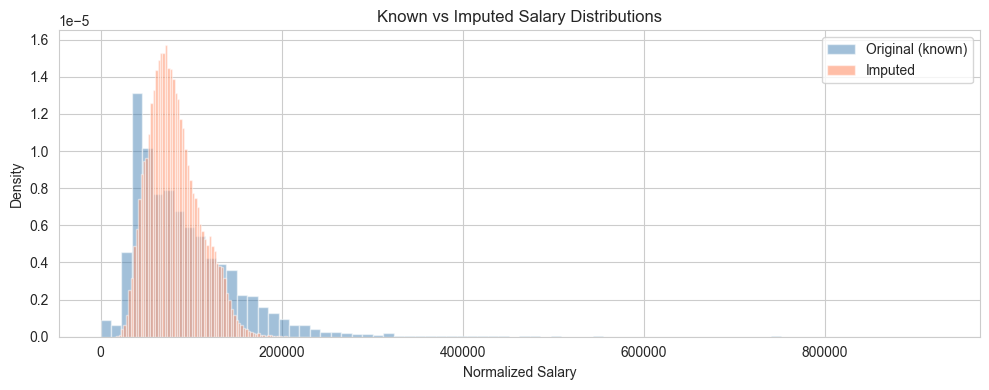

In [ ]:
# Quick sanity check: compare distributions
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_known, bins=80, alpha=0.5, label='Original (known)', density=True, color='steelblue')
ax.hist(
    df_train.loc[train_missing_mask, TARGET], bins=80,
    alpha=0.5, label='Imputed', density=True, color='coral'
)
ax.set_xlabel('Normalized Salary')
ax.set_ylabel('Density')
ax.set_title('Known vs Imputed Salary Distributions')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Export Updated Feature Matrices

In [ ]:
TRAIN_OUT = "../data/processed/v2/feature_matrix_train_v2.csv"
TEST_OUT  = "../data/processed/v2/feature_matrix_test_v2.csv"

df_train.to_csv(TRAIN_OUT, index=False)
df_test.to_csv(TEST_OUT, index=False)

print(f"Saved train: {TRAIN_OUT} ({df_train.shape})")
print(f"Saved test:  {TEST_OUT}  ({df_test.shape})")

Saved train: ../data/processed/v2/feature_matrix_train_v2.csv ((98589, 44))
Saved test:  ../data/processed/v2/feature_matrix_test_v2.csv  ((24709, 44))


## Summary

| Step | Detail |
|------|--------|
| Model | LightGBM Regressor (80/20 train/val split, early stopping) |
| Features | All non-leaky columns from the feature matrix |
| Imputation | Single model predictions |
| Output | Writes into `feature_matrix_trainv2/train.csv` with filled salary |